In [1]:
import pandas as pd 
import numpy as np


In [2]:
df=pd.read_csv('moonDataset.csv')
df.head()

,X1,X2,X3,label
0,-0.926767,-0.111073,0.086017,0
1,-0.917583,0.706006,0.058041,0
2,0.437984,0.899093,0.072543,0
3,0.089694,0.291446,0.070444,1
4,0.110672,-0.070806,-0.090376,1


In [3]:
train_df=df.sample(frac=0.75,random_state=21)
test_df=df.drop(train_df.index)

In [4]:
print(train_df.shape)
print(test_df.shape)

(150, 4)
(50, 4)


### **a. Bootstrap samplimg 20 datasets**

In [5]:
B = 20
bootstrap_dfs = []

for b in range(B):
    boot_df = train_df.sample(n=len(train_df),replace=True )
    bootstrap_dfs.append(boot_df)

print(len(bootstrap_dfs))        
print(bootstrap_dfs[0].shape)


20
(150, 4)


### **b.FNN**

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
n_features=3 #3 columns /features
model = Sequential([
    Dense(10, activation='relu', input_shape=(n_features,)),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()  


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                40        
                                                                 
 dense_1 (Dense)             (None, 1)                 11        
                                                                 
Total params: 51
Trainable params: 51
Non-trainable params: 0
_________________________________________________________________


In [7]:
X_test=test_df.drop(columns='label')
y_test=test_df['label']
y_test.shape

(50,)

In [8]:
results = {
    'idx':   [],
    'acc':   [],
    'error': []
}

In [9]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score
idx=0
for b in tqdm(bootstrap_dfs):
    X_train=b.drop(columns='label')
    y_train=b['label']
    idx+=1
    model.fit(X_train, y_train,epochs=10,batch_size=32,verbose=0)
    y_pred_proba = model.predict(X_test).ravel()   
    y_pred = (y_pred_proba >= 0.5).astype(int)
    y_true = np.array(y_test).ravel()
    acc=accuracy_score(y_true,y_pred)
    error=1-acc
    results['idx'].append(idx)
    results['acc'].append(acc)
    results['error'].append(error)
    
    


                


  0%|          | 0/20 [00:00<?, ?it/s]

2/2 [==============================] - 0s 2ms/step


  5%|▌         | 1/20 [00:01<00:22,  1.19s/it]

2/2 [==============================] - 0s 2ms/step


 10%|█         | 2/20 [00:01<00:12,  1.45it/s]

...

 90%|█████████ | 18/20 [00:04<00:00,  5.01it/s]

2/2 [==============================] - 0s 2ms/step


 95%|█████████▌| 19/20 [00:04<00:00,  5.00it/s]

2/2 [==============================] - 0s 1ms/step


100%|██████████| 20/20 [00:05<00:00,  3.91it/s]


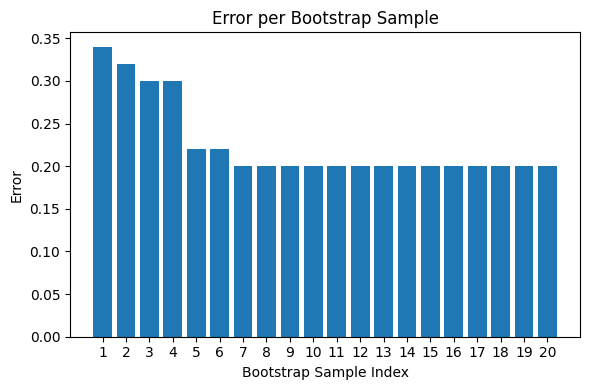

In [10]:
import matplotlib.pyplot as plt

idx = results['idx']
err = results['error']

plt.figure(figsize=(6, 4))
plt.bar(idx, err)


plt.xticks(idx, idx)  

plt.xlabel('Bootstrap Sample Index')
plt.ylabel('Error')
plt.title('Error per Bootstrap Sample')
plt.tight_layout()
plt.show()


### **c.Bagging**

In [11]:
bagging_models = []


In [12]:
for b in tqdm(bootstrap_dfs):
    X_train = b.drop(columns='label')
    y_train = b['label']
    model.fit(
        X_train, y_train,
        epochs=10,
        batch_size=32,
        verbose=0
    )
    bagging_models.append(model)


100%|██████████| 20/20 [00:03<00:00,  6.36it/s]


In [13]:
print(f"Trained {len(bagging_models)} base models.")

Trained 20 base models.


In [14]:
def ensemble_error(models_subset):
    all_prob = []
    for m in models_subset:
          proba = m.predict(X_test, verbose=0).ravel()
    all_prob.append(proba)

  
    mean_proba = np.mean(all_prob, axis=0)
    y_pred = (mean_proba >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    err=1-acc
    return err 

In [15]:
m_values = [5, 10, 15, 20]
errors_m = []

Ensemble size m = 5, error rate = 0.1800
Ensemble size m = 10, error rate = 0.1800
Ensemble size m = 15, error rate = 0.1800
Ensemble size m = 20, error rate = 0.1800


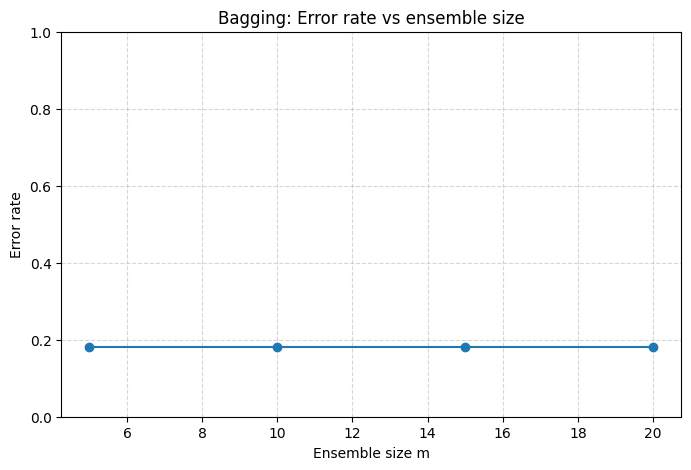

In [16]:
for m in m_values:
    models_subset = bagging_models[:m]
    err = ensemble_error(models_subset)
    errors_m.append(err)
    print(f"Ensemble size m = {m}, error rate = {err:.4f}")

# Plot error rate vs ensemble size m
plt.figure(figsize=(8, 5))
plt.plot(m_values, errors_m, marker='o')
plt.xlabel("Ensemble size m")
plt.ylabel("Error rate")
plt.title("Bagging: Error rate vs ensemble size")
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()